In [1]:
import pandas as pd
import quantitative_and_technical_analytics as statlib

TEXT_COLORS = {
    "positive": "#007919",
    "negative": "#ff4949"
}

In [2]:
javascript_string = """<script>
    function toggleSection(header) {
        const content = header.nextElementSibling;
        const isHidden = window.getComputedStyle(content).display === "none";
        if (isHidden) {
            content.style.display = "block";
            header.classList.remove("collapsed");
        } else {
            content.style.display = "none";
            header.classList.add("collapsed");
        }
    }
    const headers = document.querySelectorAll(".toggle-header");

    window.addEventListener("scroll", () => {
        headers.forEach(header => {
            const top = header.getBoundingClientRect().top;

            if (top <= 0) {
                header.classList.add("stuck");
            } else {
                header.classList.remove("stuck");
            }
        });
    });

    function updateScrollBehavior() {
        document.querySelectorAll('.content-box').forEach(box => {
            if (box.scrollWidth > box.clientWidth) {
                box.classList.add('scrollable');
            } else {
                box.classList.remove('scrollable');
            }
        });
    }

    window.addEventListener('load', updateScrollBehavior);
    window.addEventListener('resize', updateScrollBehavior);
</script>"""

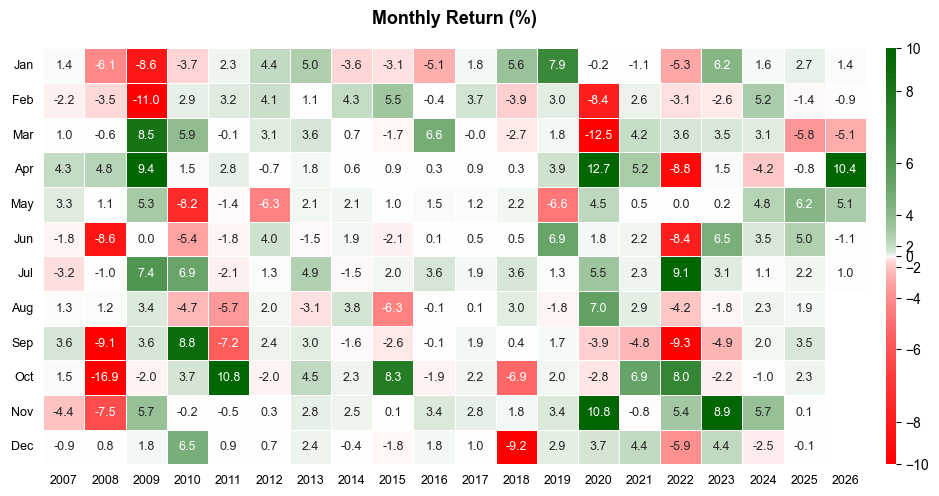

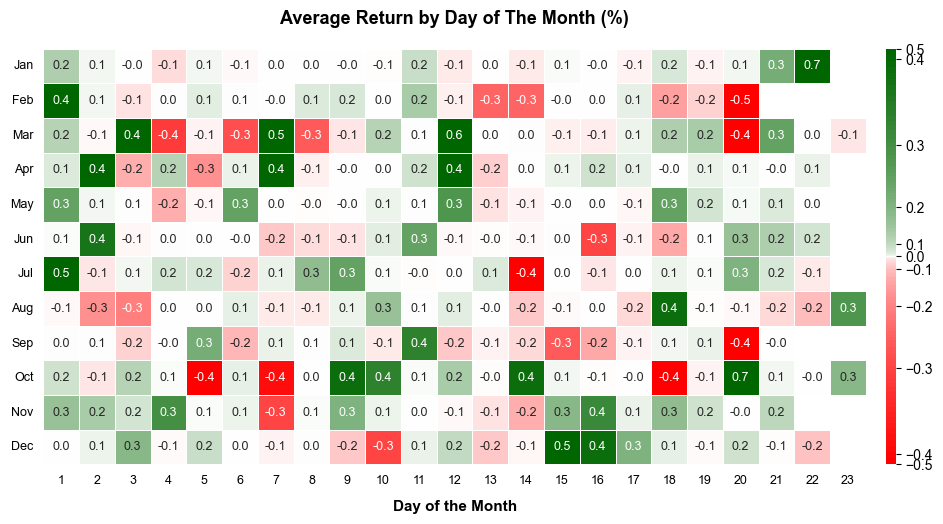

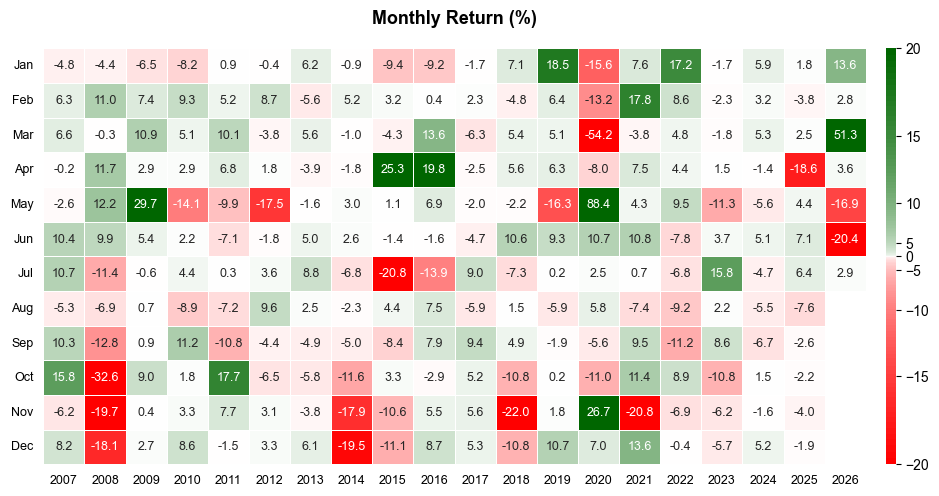

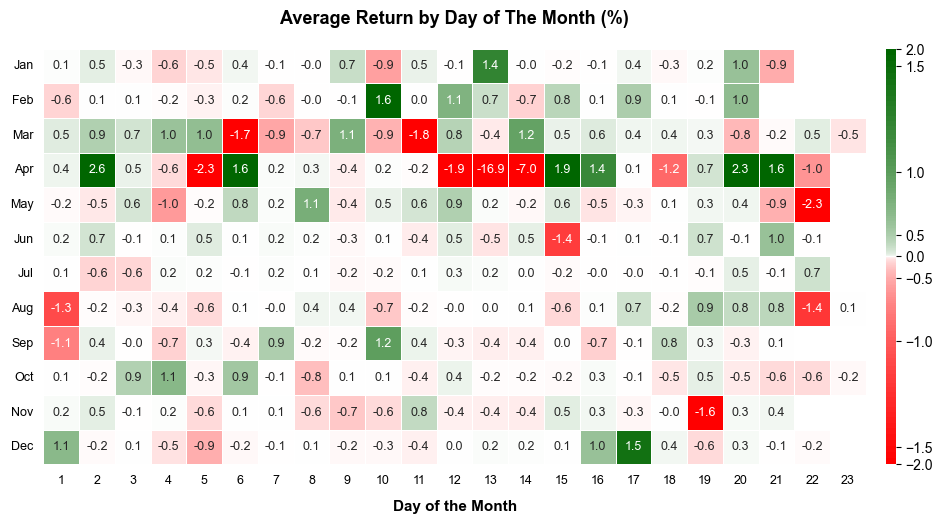

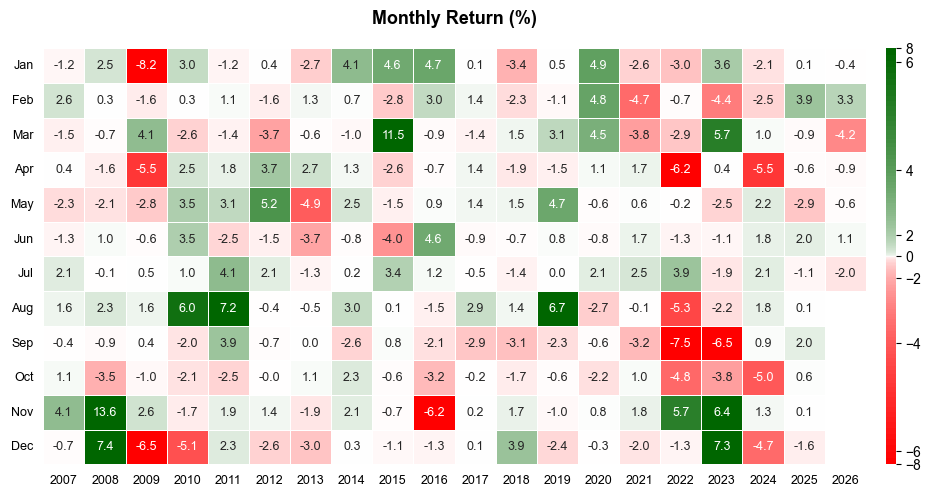

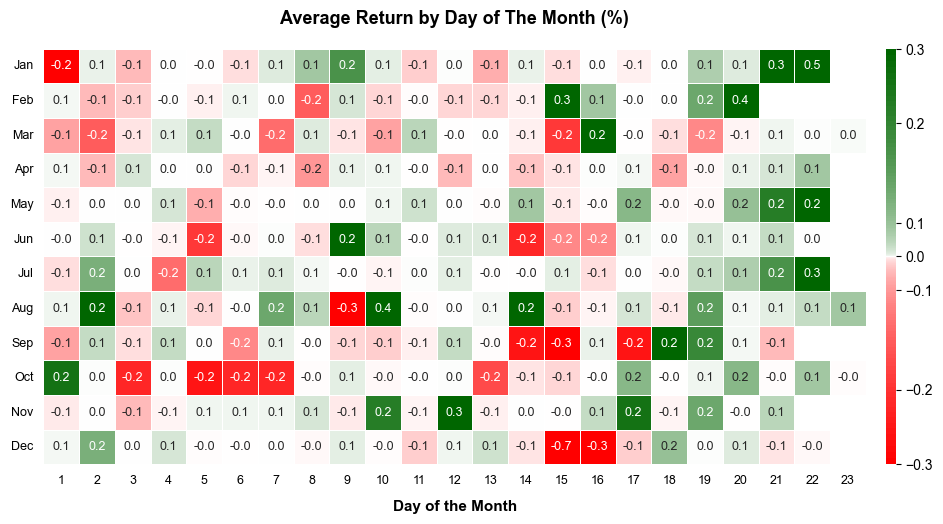

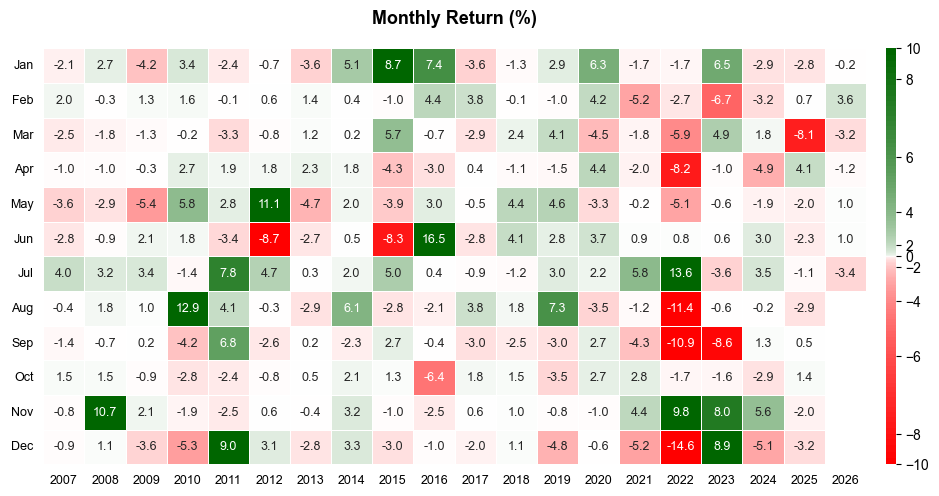

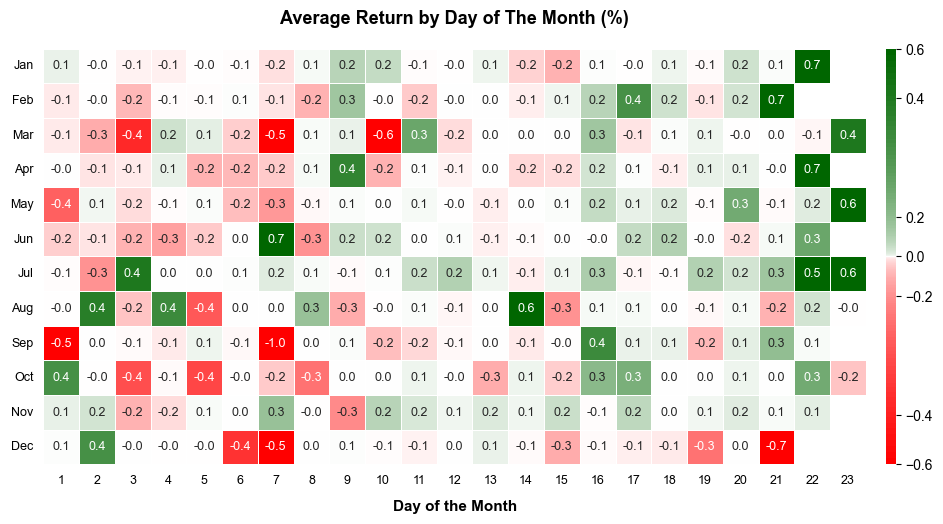

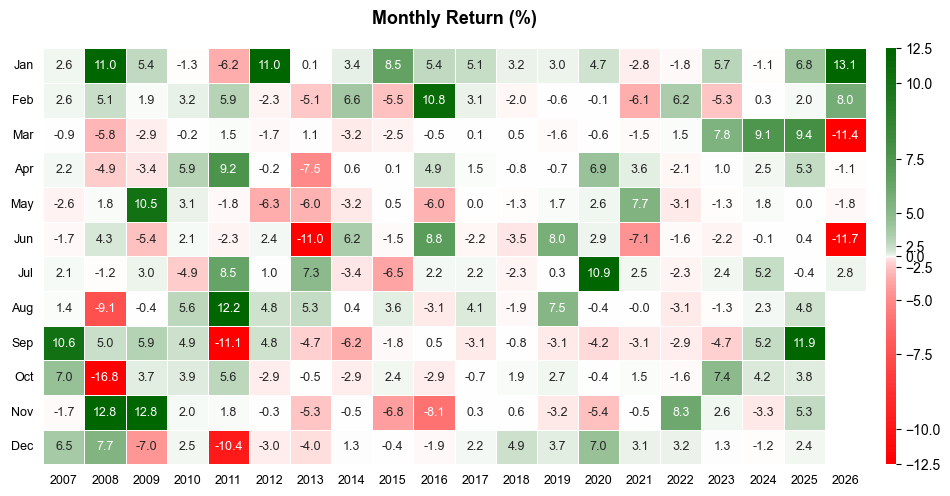

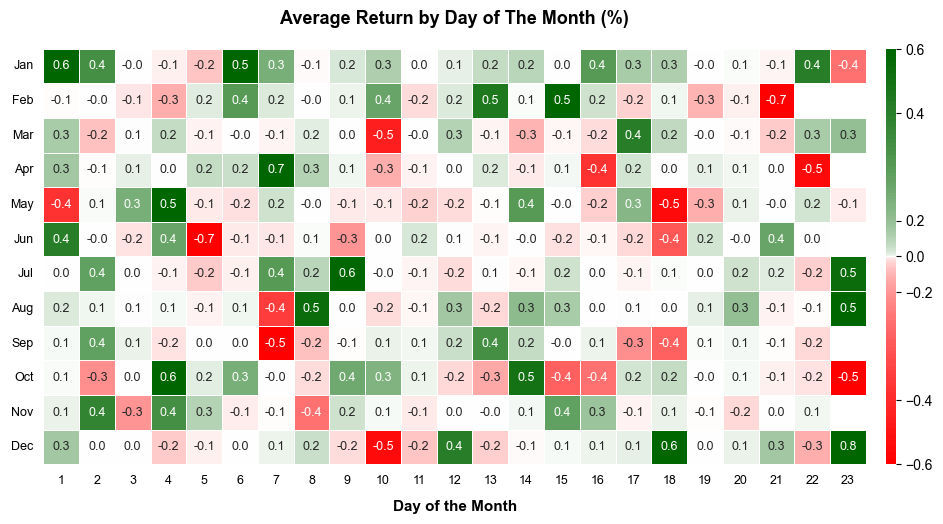

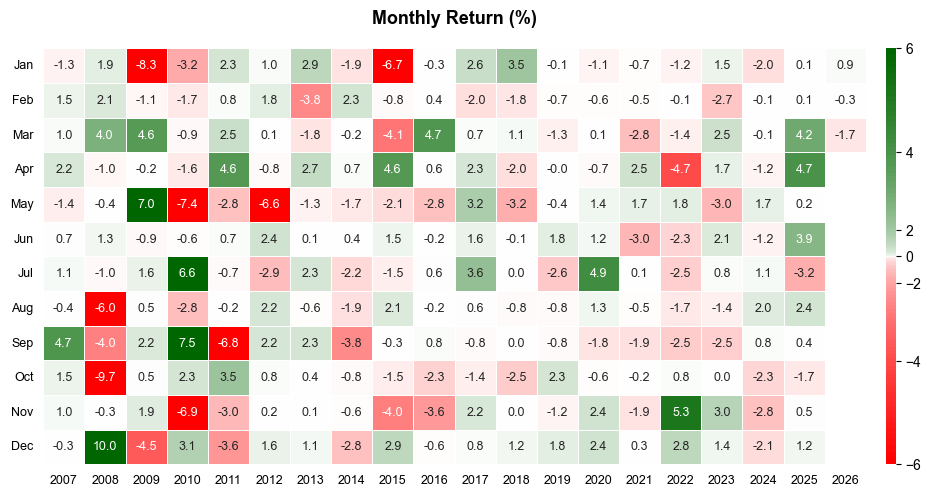

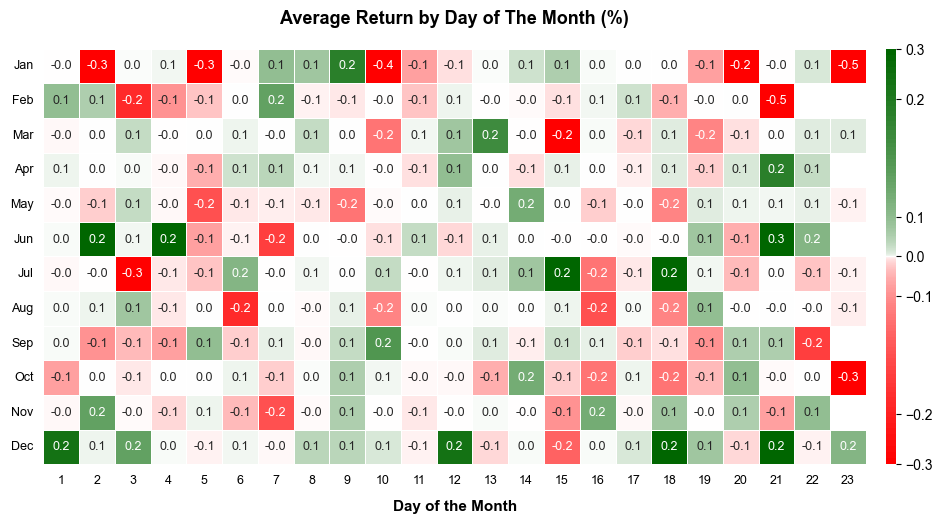

In [3]:
ticker_list = ["SPX", "CL", "ZB", "GBX", "XAUUSD", "EURUSD"]
ticker_description = ["S&P 500", "WTI Crude Oil", "US 30Y Treasury Bond", "Euro Buxl", "Gold Spot USD", "EURUSD"]
ticker_initial_date = ["1989-12-29", "2008-12-31", "1989-12-29", "2005-12-29", "2004-12-29", "1998-12-30"]

initial_html_string = """<!DOCTYPE html><html lang="en"><head><meta charset="UTF-8"><title>Numbers & Markets — Market Statistics</title><meta name="description" content="Daily market statistics across global assets including daily and weekly price, realized volatility, risk and returns."><meta name="keywords" content="Market statistics, realized volatility financial data, quant analysis, asset returns."><meta name="author" content="Luis Filipe"><meta name="viewport" content="width=device-width, initial-scale=1.0"><meta property="og:title" content="Numbers & Markets — Market Statistics"><meta property="og:description" content="Daily cross-asset statistics: daily and weekly price, realized volatility and returns."><link rel="stylesheet" href="css/style.css"></head><body><div class="container"><h1>Numbers & Markets</h1>"""
final_html_string = """</div><div class="disclaimer"><div><h3>Disclaimer</h3><p>The information presented on this website is provided for informational and educational purposes only. It does not constitute investment advice, financial advice, trading advice, or any other type of recommendation, and should not be relied upon as such. All data, statistics, and analyses are provided “as is” without any representations or warranties, express or implied, including but not limited to accuracy, completeness, or timeliness. While reasonable efforts may be made to ensure the quality of the information, errors or omissions may occur. No statement, indication, sign, value or number on this website should be interpreted as a solicitation, recommendation, or endorsement to buy, sell, or hold any financial instrument, including but not limited to equities, commodities, indices, currencies, or derivatives. The author assumes no responsibility or liability for any losses, damages, or other consequences resulting from the use of, or reliance on, the information presented on this website. Any decisions made based on this information are the sole responsibility of the user. Users are encouraged to conduct their own research and consult with a qualified financial professional before making any investment decisions. Data may be sourced from third-party providers and is subject to their respective terms and potential inaccuracies. This website is not intended for use in jurisdictions where such information would be contrary to local laws or regulations.</p></div></div></body></html>"""
complete_page_string = initial_html_string
delimiter = ""

for i in range(len(ticker_list)):
    ticker = ticker_list[i]
    description = ticker_description[i]
    initial_date = ticker_initial_date[i]

    dataframe_complete = pd.read_csv(f"/Users/Luis Rito/Data Science - Estudos/Financial Analysis/{ticker}.csv")
    dataframe_complete = dataframe_complete.where(dataframe_complete['Date'] > '1956-12-29').dropna().reset_index(drop=True) # SP500 was expanded to 500 companies on 4th of March 1957
    df_weekly = statlib.convert_daily_to_weekly_quotes(f"{ticker}", dataframe_complete)
    df_weekly = statlib.simple_moving_average(df_weekly, 32)
    df_weekly = statlib.sup_trend(df_weekly, 10, 0.5)
    df_weekly = statlib.up_down_5_10_20_percent(df_weekly)
    df_weekly = statlib.realized_volatility(df_weekly, [4, 13])
    df_weekly = df_weekly.where(df_weekly['Date'] > initial_date).dropna().reset_index(drop=True)
    df_monthly = statlib.convert_daily_to_monthly_quotes(f"{ticker}", dataframe_complete)
    df = dataframe_complete.where(dataframe_complete['Date'] > initial_date).dropna().reset_index(drop=True)
    df = statlib.simple_moving_average(df, 32)
    df = statlib.sup_trend(df, 10, 0.5)
    df = statlib.up_down_5_10_20_percent(df)
    df = statlib.realized_volatility(df, [5, 21])
    df = df.where(df['Date'] > initial_date).dropna().reset_index(drop=True)
    statlib.intraday_and_end_of_day_price_statistics(ticker, df)
    statlib.daily_volatility_regime(ticker, df)
    statlib.rv_regime_and_percentile_chart(ticker, df)
    statlib.range_by_day_of_the_week(ticker, df, start_date=initial_date, end_date="2026-12-31")
    statlib.intraweek_and_end_of_week_price_statistics(ticker, df_weekly, df)
    statlib.weekly_trend(ticker, df_weekly, df)
    statlib.return_21_day(ticker, df)
    statlib.seasonality_chart(ticker, df)
    statlib.time_cycles_chart(ticker, df, 90) if (ticker == "SPX") else False
    statlib.MonthlyStats(ticker, df_monthly).average_monthly_returns_chart()
    statlib.MonthlyStats(ticker, df_monthly).heatmap()
    statlib.returns_by_day_of_the_month(ticker, dataframe_complete, start_date=initial_date, end_date="2026-12-31")

    high = (100 * ( (df_weekly["High"].iloc[-1] / df_weekly["Close"].iloc[-2]) - 1) ).round(2)
    low = (100 * ( (df_weekly["Low"].iloc[-1] / df_weekly["Close"].iloc[-2]) - 1) ).round(2)
    last = (100 * ( (df_weekly["Close"].iloc[-1] / df_weekly["Close"].iloc[-2]) - 1) ).round(2)
    high = f"""<span style="color:{TEXT_COLORS["positive"]};">{high}%</span>""" if (high >= 0) else f"""<span style="color:{TEXT_COLORS["negative"]};">{high}%</span>"""
    low = f"""<span style="color:{TEXT_COLORS["positive"]};">{low}%</span>""" if (low >= 0) else f"""<span style="color:{TEXT_COLORS["negative"]};">{low}%</span>"""
    last = f"""<span style="color:{TEXT_COLORS["positive"]};">{last}%</span>""" if (last >= 0) else f"""<span style="color:{TEXT_COLORS["negative"]};">{last}%</span>"""
    quotes = f"High: {high} | Low: {low} | Last: {last}"

    file_path = f"tables/{ticker}_intraday_and_end_of_day_price_statistics.html"
    with open(file_path, "r", encoding="utf-8") as f:
        intraday_and_end_of_day_price_statistics = f.read()
    file_path = f"tables/{ticker}_daily_volatility_regime.html"
    with open(file_path, "r", encoding="utf-8") as f:
        daily_volatility_regime = f.read()
    file_path = f"tables/{ticker}_range_by_day_of_the_week.html"
    with open(file_path, "r", encoding="utf-8") as f:
        range_by_day_of_the_week = f.read()
    file_path = f"tables/{ticker}_intraweek_and_end_of_week_price_statistics.html"
    with open(file_path, "r", encoding="utf-8") as f:
        intraweek_and_end_of_week_price_statistics = f.read()
    file_path = f"tables/{ticker}_weekly_trend.html"
    with open(file_path, "r", encoding="utf-8") as f:
        weekly_trend = f.read()
    file_path = f"tables/{ticker}_highest_range_after_Xdrop_of_21_day_return.html"
    with open(file_path, "r", encoding="utf-8") as f:
        highest_range_after_Xdrop_of_21_day_return = f.read()
    file_path = f"tables/{ticker}_lowest_range_after_Xdrop_of_21_day_return.html"
    with open(file_path, "r", encoding="utf-8") as f:
        lowest_range_after_Xdrop_of_21_day_return = f.read()
    
    page_sections_list = [
        """<section class="instrument">""",
        f"""<h2 onclick="toggleSection(this)" class="toggle-header collapsed">{description}<span class="arrow">▼</span></h2>""",
        """<div class="instrument-content">""",
        """<h3>Daily Statistics</h3>""",
        """<div class="subsection">""",
        """<h4>Intraday and End-of-Day Price Statistics</h4>""",
        f"""<div id="{ticker}_intraday_and_end_of_day_price_statistics" class="content-box">{intraday_and_end_of_day_price_statistics}</div>""",
        """</div>""",
        """<div class="subsection">""",
        """<h4>Volatility Regime</h4>""",
        f"""<div id="{ticker}_daily_volatility_regime" class="content-box">{daily_volatility_regime}</div>""",
        """</div>""",
        """<div class="subsection">""",
        f"""<div id="{ticker}_rv_regime_and_percentile_chart" class="content-box"><img src="charts/{ticker}_rv_regime_and_percentile_chart.svg"></div>""",
        """</div>""",
        f"""<h3>Weekly Statistics <span>({quotes})</span></h3>""",
        """<div class="subsection">""",
        """<h4>Range by Day of the Week</h4>""",
        f"""<div id="{ticker}_range_by_day_of_the_week" class="content-box">{range_by_day_of_the_week}</div>""",
        """</div>""",
        """<div class="subsection">""",
        f"""<h4>Intraweek and End-of-Week Price Statistics</h4>""",
        f"""<div id="{ticker}_intraweek_and_end_of_week_price_statistics" class="content-box">{intraweek_and_end_of_week_price_statistics}</div>""",
        """</div>""",
        """<div class="subsection">""",
        f"""<div id="{ticker}_weekly_trend" class="content-box">{weekly_trend}</div>""",
        """</div>""",
        """<div class="subsection">""",
        f"""<div id="{ticker}_21_day_return_chart" class="content-box"><img src="charts/{ticker}_21_day_return_chart.svg"></div>""",
        """</div>""",
        """<div class="subsection">""",
        """<h4>Historical Maximum Subsequent Return (%) After Declines in 21-Day Return</h4>""",
        f"""<div id="{ticker}_highest_range_after_Xdrop_of_21_day_return" class="content-box">{highest_range_after_Xdrop_of_21_day_return}</div>""",
        """</div>""",
        """<div class="subsection">""",
        """<h4>Historical Maximum Subsequent Drawdown (%) After Declines in 21-Day Return</h4>""",
        f"""<div id="{ticker}_lowest_range_after_Xdrop_of_21_day_return" class="content-box">{lowest_range_after_Xdrop_of_21_day_return}</div>""",
        """</div>""",
        """<h3>Seasonality</h3>""",
        *([f"""<div class="subsection"><div id="{ticker}_time_cycles_chart" class="content-box"><img src="charts/{ticker}_time_cycles_chart.svg"></div></div>"""] if (ticker == "SPX") else []),
        """<div class="subsection">""",
        f"""<div id="{ticker}_seasonality_chart" class="content-box"><img src="charts/{ticker}_seasonality_chart.svg"></div>""",
        """</div>""",
        """<div class="subsection">""",
        f"""<div id="{ticker}_average_monthly_return_chart" class="content-box"><img src="charts/{ticker}_average_monthly_return_chart.svg"></div>""",
        """</div>""",
        """<div class="subsection">""",
        f"""<div id="{ticker}_monthly_return_heatmap" class="content-box"><img src="charts/{ticker}_monthly_return_heatmap.svg"></div>""",
        """</div>""",
        """<div class="subsection">""",
        f"""<div id="{ticker}_average_return_by_day_of_the_month" class="content-box"><img src="charts/{ticker}_average_return_by_day_of_the_month.svg"></div>""",
        """</div>""",
        """</div>""",
        """</section>"""
    ]

    complete_page_string += delimiter.join(page_sections_list)

complete_page_string += final_html_string
complete_page_string += javascript_string

with open("index.html", "w", encoding="utf-8") as f:
    f.write(complete_page_string)